### Agents Analytics that are trained against random
#### ver50 stands for 5 - number of rows (4x5 board - 16 pieces), 0 - no self play (trained against random)

*Note: all configs, parameters and hyperparameters used in this phase are available in "../implementations/ver50/configs.ipynb"*

versions guide:
- M - 0 (cannot happen in current setup)
- N - 0 (is not implemented in current setup)
- X - {0: no, 1: yes}
- 50XYYMNY, X - Is Double Net
- 50YXYMNY, X - Is Dueling Net
- 50YYXMNY, X - Is Residual Net
- 50YYYMNX, X - Will do slight reward shaping

#### Training Data

| ver | label                    | max Q (training) | min Q (training) | avg Q (first eval) | avg Q (last eval) | win% (half) | draw% (half) | loss% (half) | **win% (end)** | draw% (end) | loss% (end) | Beat baseline |
|---:|--------------------------|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|:---:|
| 50101000 | **ResDDQN**              | 0.9926 | -0.0604 | 0.5062 | 0.8189 | 64.0% | 32.0% | 4.0% | **90.0%** | 10.0% | 0.0% | Yes |
| 50111000 | **ResDuelingDDQN**       | 1.0538 | 0.3663 | 0.6843 | 0.8324 | 32.0% | 56.0% | 12.0% | **77.5%** | 19.5% | 3.0% | Yes |
| 50101001 | **RewardShapingResDDQN** | 0.9765 | 0.1327 | 0.6731 | 0.8582 | 43.0% | 45.5% | 11.5% | **71.5%** | 24.5% | 4.0% | Yes |
| 50100000 | **DDQN**                 | 1.4683 | 0.1028 | 0.4435 | 0.7970 | 23.1% | 63.8% | 13.1% | **70.0%** | 26.5% | 3.5% | Yes |
| 50110000 | **DuelingDDQN**          | 2.1152 | 0.1263 | 0.5148 | 0.8133 | 18.2% | 67.2% | 14.6% | **59.5%** | 35.5% | 5.0% | Yes |
| 50100001 | **RewardShapingDDQN**    | 2.0181 | 0.1451 | 0.5955 | 0.8493 | 17.5% | 70.0% | 12.5% | **59.5%** | 35.5% | 5.0% | Yes |
| 50000000 | **DQN**                  | 1595.5819 | 0.4853 | 104.3568 | 0.6171 | 16.0% | 75.0% | 9.0% | **24.5%** | 70.0% | 5.5% | Yes |

*Note: random vs random baseline is available in "random_vs_random_baseline.ipynb"*

In [1]:
import torch
from collections import Counter
from domain.configs import ROWS, COLUMNS, MAX_STEPS_PER_EPISODE
from environment.action_encoder import ActionEncoder
from environment.grenight_environment import GrenightEnvironment
from agent.grenight_agent import GrenightAgent
from environment.piece_plane_encoder import PiecePlaneEncoder

In [3]:
env = GrenightEnvironment(is_canonical_version=True,
                          will_store_history_in_state=False,
                          will_do_reward_shaping=False)

env.action_encoder = ActionEncoder(is_canonical_version=False)
# intentional modification because agents are trained of absolute space where number of actions is bigger
# than canonical version, but canonical is faster solution for testing agents that are trained as white vs random


def generate_new_agent(is_self_play: bool,
                       is_double_net: bool,
                       is_dueling_net: bool,
                       is_residual_net: bool,
                       is_historical_net: bool | None=False) -> GrenightAgent:

    return GrenightAgent(
        is_self_play=is_self_play,
        is_double_net=is_double_net,
        is_dueling_net=is_dueling_net,
        is_residual_net=is_residual_net,
        is_bulk_update=False,
        rows=ROWS,
        columns=COLUMNS,
        num_actions=env.action_encoder.num_actions,
        num_planes=PiecePlaneEncoder.NUM_PLANES_HISTORICAL if is_historical_net else PiecePlaneEncoder.NUM_PLANES_ONLY_CURRENT,
        device="cpu"
    )


def load_checkpoint(path: str, agent: GrenightAgent):
    checkpoint = torch.load(path, map_location="cpu",weights_only=False)
    agent.policy_net.load_state_dict(checkpoint["policy_state_dict"])
    if agent.is_double_net:
        agent.target_net.load_state_dict(checkpoint["target_state_dict"])
    agent.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    agent.train_steps = checkpoint["train_steps"]


dqn = generate_new_agent(False, False, False, False)
load_checkpoint("../implementations/ver50/p_000000/current_implementation_ep8000.pt", dqn)

ddqn = generate_new_agent(False, True, False, False)
load_checkpoint("../implementations/ver50/p_100000/current_implementation_ep8000.pt", ddqn)

dueling_ddqn = generate_new_agent(False, True, True, False)
load_checkpoint("../implementations/ver50/p_110000/current_implementation_ep8000.pt", dueling_ddqn)

res_ddqn = generate_new_agent(False, True, False, True)
load_checkpoint("../implementations/ver50/p_101000/current_implementation_ep8000.pt", res_ddqn)

res_dueling_ddqn = generate_new_agent(False, True, True, True)
load_checkpoint("../implementations/ver50/p_111000/current_implementation_ep8000.pt", res_dueling_ddqn)

reward_shaping_ddqn = generate_new_agent(False, True, False, False)
load_checkpoint("../implementations/ver50/p_100001/current_implementation_ep8000.pt", reward_shaping_ddqn)

reward_shaping_res_ddqn = generate_new_agent(False, True, False, True)
load_checkpoint("../implementations/ver50/p_101001/current_implementation_ep8000.pt", reward_shaping_res_ddqn)

agents = {
    "dqn": dqn,
    "ddqn": ddqn,
    "dueling_ddqn": dueling_ddqn,
    "res_ddqn": res_ddqn,
    "res_dueling_ddqn": res_dueling_ddqn,
    "reward_shaping_ddqn": reward_shaping_ddqn,
    "reward_shaping_res_ddqn": reward_shaping_res_ddqn
}


def test_agents(left_agent, right_agent, left_name, right_name):

    outcomes = Counter()

    for _ in range(1000):
        env.reset()
        env.previous_pieces_encoded_q.queue.clear()

        move_count = 0
        is_white_on_turn = True
        is_draw = False
        done = False

        while move_count < MAX_STEPS_PER_EPISODE and not done:
            is_white_on_turn = True

            left_state = env.get_state()
            left_mask = env.action_mask()
            left_act = left_agent.select_action(left_state, left_mask, 0.05)

            _, _, done, is_draw, _ = env.step(left_act)
            move_count += 1

            if move_count < MAX_STEPS_PER_EPISODE and not done:
                is_white_on_turn = False

                right_state = env.get_state()
                right_mask = env.action_mask()
                right_act = right_agent.select_action(right_state, right_mask, 0.05)

                _, _, done, is_draw, _ = env.step(right_act)
                move_count += 1

        if not done:
            outcomes["truncated"] += 1
        else:
            if is_draw:
                outcomes["draw"] += 1
            else:
                outcomes["white_win" if is_white_on_turn else "black_win"] += 1

    print(f"STATS OUT FROM: {10} GAMES\n"
          f"white={left_name}, black={right_name}\n"
          f"Outcomes: {outcomes}\n")


for ik, i_agent in agents.items():
    for jk, j_agent in agents.items():
        if ik == jk:
            continue
        test_agents(i_agent, j_agent, ik, jk)

STATS OUT FROM: 10 GAMES
white=dqn, black=ddqn
Outcomes: Counter({'draw': 6, 'white_win': 4})

STATS OUT FROM: 10 GAMES
white=dqn, black=dueling_ddqn
Outcomes: Counter({'draw': 9, 'black_win': 1})

STATS OUT FROM: 10 GAMES
white=dqn, black=res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 3})

STATS OUT FROM: 10 GAMES
white=dqn, black=res_dueling_ddqn
Outcomes: Counter({'draw': 9, 'black_win': 1})

STATS OUT FROM: 10 GAMES
white=dqn, black=reward_shaping_ddqn
Outcomes: Counter({'white_win': 5, 'draw': 5})

STATS OUT FROM: 10 GAMES
white=dqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 2, 'black_win': 1})

STATS OUT FROM: 10 GAMES
white=ddqn, black=dqn
Outcomes: Counter({'white_win': 8, 'draw': 2})

STATS OUT FROM: 10 GAMES
white=ddqn, black=dueling_ddqn
Outcomes: Counter({'white_win': 6, 'draw': 4})

STATS OUT FROM: 10 GAMES
white=ddqn, black=res_ddqn
Outcomes: Counter({'white_win': 4, 'draw': 4, 'black_win': 2})

STATS OUT FROM: 10 GAMES
white=ddqn, blac

=== Overall score ranking ===
                  agent  games  win_pct  draw_pct  loss_pct  score_pct
       res_dueling_ddqn    120     42.5      42.5      15.0       63.7
reward_shaping_res_ddqn    120     47.5      25.8      26.7       60.4
               res_ddqn    120     41.7      34.2      24.2       58.8
           dueling_ddqn    120     20.8      47.5      31.7       44.6
                   ddqn    120     23.3      41.7      35.0       44.2
                    dqn    120     14.2      54.2      31.7       41.2
    reward_shaping_ddqn    120     13.3      47.5      39.2       37.1

Saved figure to ver50_plots.png


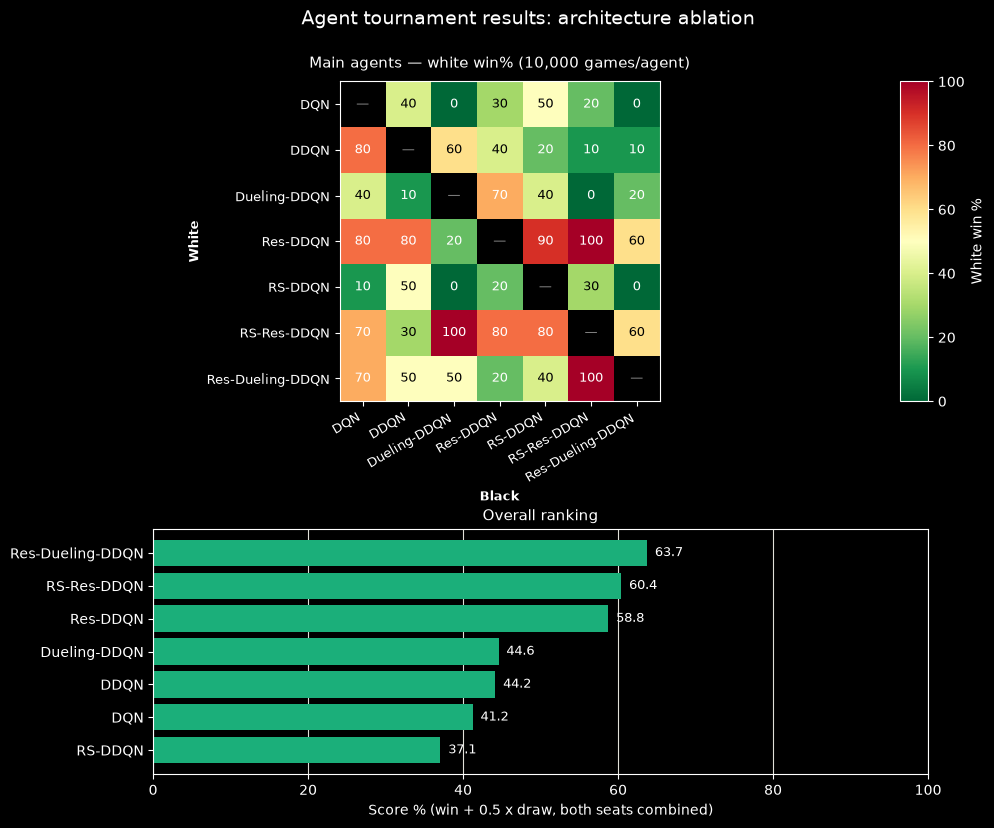

In [13]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RAW_STATS = """
white=dqn, black=ddqn
Outcomes: Counter({'draw': 6, 'white_win': 4})
white=dqn, black=dueling_ddqn
Outcomes: Counter({'draw': 9, 'black_win': 1})
white=dqn, black=res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 3})
white=dqn, black=res_dueling_ddqn
Outcomes: Counter({'draw': 9, 'black_win': 1})
white=dqn, black=reward_shaping_ddqn
Outcomes: Counter({'white_win': 5, 'draw': 5})
white=dqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 2, 'black_win': 1})
white=ddqn, black=dqn
Outcomes: Counter({'white_win': 8, 'draw': 2})
white=ddqn, black=dueling_ddqn
Outcomes: Counter({'white_win': 6, 'draw': 4})
white=ddqn, black=res_ddqn
Outcomes: Counter({'white_win': 4, 'draw': 4, 'black_win': 2})
white=ddqn, black=res_dueling_ddqn
Outcomes: Counter({'black_win': 5, 'draw': 4, 'white_win': 1})
white=ddqn, black=reward_shaping_ddqn
Outcomes: Counter({'draw': 6, 'black_win': 2, 'white_win': 2})
white=ddqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'black_win': 7, 'draw': 2, 'white_win': 1})
white=dueling_ddqn, black=dqn
Outcomes: Counter({'draw': 6, 'white_win': 4})
white=dueling_ddqn, black=ddqn
Outcomes: Counter({'draw': 5, 'black_win': 4, 'white_win': 1})
white=dueling_ddqn, black=res_ddqn
Outcomes: Counter({'white_win': 7, 'draw': 2, 'black_win': 1})
white=dueling_ddqn, black=res_dueling_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 2, 'black_win': 1})
white=dueling_ddqn, black=reward_shaping_ddqn
Outcomes: Counter({'white_win': 4, 'draw': 4, 'black_win': 2})
white=dueling_ddqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'black_win': 7, 'draw': 3})
white=res_ddqn, black=dqn
Outcomes: Counter({'white_win': 8, 'draw': 1, 'black_win': 1})
white=res_ddqn, black=ddqn
Outcomes: Counter({'white_win': 8, 'draw': 2})
white=res_ddqn, black=dueling_ddqn
Outcomes: Counter({'draw': 6, 'white_win': 2, 'black_win': 2})
white=res_ddqn, black=res_dueling_ddqn
Outcomes: Counter({'white_win': 6, 'draw': 4})
white=res_ddqn, black=reward_shaping_ddqn
Outcomes: Counter({'white_win': 9, 'draw': 1})
white=res_ddqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'white_win': 10})
white=res_dueling_ddqn, black=dqn
Outcomes: Counter({'white_win': 7, 'draw': 2, 'black_win': 1})
white=res_dueling_ddqn, black=ddqn
Outcomes: Counter({'white_win': 5, 'draw': 5})
white=res_dueling_ddqn, black=dueling_ddqn
Outcomes: Counter({'white_win': 5, 'draw': 4, 'black_win': 1})
white=res_dueling_ddqn, black=res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 2, 'black_win': 1})
white=res_dueling_ddqn, black=reward_shaping_ddqn
Outcomes: Counter({'draw': 6, 'white_win': 4})
white=res_dueling_ddqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'white_win': 10})
white=reward_shaping_ddqn, black=dqn
Outcomes: Counter({'draw': 8, 'white_win': 1, 'black_win': 1})
white=reward_shaping_ddqn, black=ddqn
Outcomes: Counter({'white_win': 5, 'draw': 4, 'black_win': 1})
white=reward_shaping_ddqn, black=dueling_ddqn
Outcomes: Counter({'draw': 7, 'black_win': 3})
white=reward_shaping_ddqn, black=res_ddqn
Outcomes: Counter({'draw': 6, 'white_win': 2, 'black_win': 2})
white=reward_shaping_ddqn, black=res_dueling_ddqn
Outcomes: Counter({'black_win': 8, 'draw': 2})
white=reward_shaping_ddqn, black=reward_shaping_res_ddqn
Outcomes: Counter({'draw': 7, 'white_win': 3})
white=reward_shaping_res_ddqn, black=dqn
Outcomes: Counter({'white_win': 7, 'draw': 3})
white=reward_shaping_res_ddqn, black=ddqn
Outcomes: Counter({'draw': 6, 'white_win': 3, 'black_win': 1})
white=reward_shaping_res_ddqn, black=dueling_ddqn
Outcomes: Counter({'white_win': 10})
white=reward_shaping_res_ddqn, black=res_ddqn
Outcomes: Counter({'white_win': 8, 'draw': 1, 'black_win': 1})
white=reward_shaping_res_ddqn, black=res_dueling_ddqn
Outcomes: Counter({'white_win': 6, 'black_win': 3, 'draw': 1})
white=reward_shaping_res_ddqn, black=reward_shaping_ddqn
Outcomes: Counter({'white_win': 8, 'draw': 1, 'black_win': 1})
"""

MAIN_AGENTS = [
    "dqn", "ddqn", "dueling_ddqn", "res_ddqn",
    "reward_shaping_ddqn", "reward_shaping_res_ddqn",
    "res_dueling_ddqn"
]

AGENT_LABELS = {
    "dqn": "DQN",
    "ddqn": "DDQN",
    "dueling_ddqn": "Dueling-DDQN",
    "res_ddqn": "Res-DDQN",
    "reward_shaping_ddqn": "RS-DDQN",
    "res_dueling_ddqn": "Res-Dueling-DDQN",
    "reward_shaping_res_ddqn": "RS-Res-DDQN"
}


def parse_games(raw: str) -> list[tuple[str, str, dict]]:
    lines = [l.strip() for l in raw.strip().split("\n") if l.strip()]
    games = []
    for i in range(0, len(lines), 2):
        m = re.match(r"white=(\w+), black=(\w+)", lines[i])
        white, black = m.group(1), m.group(2)
        counts = {k: int(v) for k, v in re.findall(r"'(\w+)': (\d+)", lines[i + 1])}
        games.append((white, black, counts))
    return games


def build_white_win_matrix(games, agents) -> pd.DataFrame:
    mat = pd.DataFrame(index=agents, columns=agents, dtype=float)
    for white, black, c in games:
        if white not in agents or black not in agents:
            continue
        total = c.get("white_win", 0) + c.get("black_win", 0) + c.get("draw", 0)
        mat.loc[white, black] = c.get("white_win", 0) / total * 100
    return mat


def build_overall_scores(games) -> pd.DataFrame:
    stats = defaultdict(lambda: {"win": 0, "loss": 0, "draw": 0, "games": 0})
    for white, black, c in games:
        ww, bw, dr = c.get("white_win", 0), c.get("black_win", 0), c.get("draw", 0)
        total = ww + bw + dr
        stats[white]["win"] += ww
        stats[white]["loss"] += bw
        stats[white]["draw"] += dr
        stats[white]["games"] += total
        stats[black]["win"] += bw
        stats[black]["loss"] += ww
        stats[black]["draw"] += dr
        stats[black]["games"] += total

    rows = []
    for agent, s in stats.items():
        if s["games"] == 0:
            continue
        rows.append({
            "agent": agent,
            "games": s["games"],
            "win_pct": s["win"] / s["games"] * 100,
            "draw_pct": s["draw"] / s["games"] * 100,
            "loss_pct": s["loss"] / s["games"] * 100,
            "score_pct": (s["win"] + 0.5 * s["draw"]) / s["games"] * 100,
        })
    return pd.DataFrame(rows).sort_values("score_pct", ascending=False).reset_index(drop=True)


def plot_heatmap(ax, matrix: pd.DataFrame, title: str):
    # Map internal agent keys to short display labels
    labels = [AGENT_LABELS.get(a, a) for a in matrix.index]
    data = matrix.to_numpy(dtype=float)

    im = ax.imshow(data, cmap="RdYlGn_r", vmin=0, vmax=100)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Black", fontsize=9, fontweight="bold")
    ax.set_ylabel("White", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=11, pad=10)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = data[i, j]
            if np.isnan(val):
                text = "\u2014"
                color = "gray"
            else:
                text = f"{val:.0f}"
                color = "white" if (val > 65 or val < 25) else "black"
            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=color)

    return im


def plot_ranking(ax, scores: pd.DataFrame):
    scores = scores.sort_values("score_pct")
    # Map internal agent keys to short display labels
    labels = [AGENT_LABELS.get(a, a) for a in scores["agent"]]

    bars = ax.barh(labels, scores["score_pct"], color="#1baf7a")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Score % (win + 0.5 x draw, both seats combined)")
    ax.set_title("Overall ranking", fontsize=11)
    ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

    for bar, val in zip(bars, scores["score_pct"]):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}",
                va="center", fontsize=9)


def main():
    games = parse_games(RAW_STATS)

    main_matrix = build_white_win_matrix(games, MAIN_AGENTS)
    scores = build_overall_scores(games)

    print("=== Overall score ranking ===")
    print(scores.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

    fig = plt.figure(figsize=(10, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], width_ratios=[1, 0.04],
                          hspace=0.45, wspace=0.15)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_rank = fig.add_subplot(gs[1, :])

    im1 = plot_heatmap(ax_main, main_matrix, "Main agents \u2014 white win% (10,000 games/agent)")
    plot_ranking(ax_rank, scores)

    fig.colorbar(im1, cax=ax_cbar, label="White win %")

    fig.suptitle("Agent tournament results: architecture ablation", fontsize=14, y=0.96)
    fig.savefig("ver50_plots.png", dpi=150, bbox_inches="tight")
    print("\nSaved figure to ver50_plots.png")


if __name__ == "__main__":
    main()

#### Conclusion
For further training pure q network will not be considered as option at all, due its instability in early training and finishing results. Other options (storing previous k boards, reward shaping and dueling architecture) will be given more opportunity on self play with more episodes to stabilize and exclude potential incompatibility against random policy opponent. As for intentional agent against random opponent residual double q network architecture performed the best on this number of episodes.